## PREDICTING H1N1 AND SEASONAL FLU VACCINES- PHASE 3 PROJECT

### PROJECT OVERVIEW

Vaccinations play a critical role in controlling infectious diseases by protecting individuals and contributing to herd immunity, making it an essential area of study in public health. This project focuses on predicting whether individuals received the H1N1 and seasonal vaccines using demographic, behavioral, and attitudinal data collected during the 2009 H1N1 flu pandemic.
 Using machine learning models, the analysis identifies key factors that influence vaccination decisions and estimates the likelihood of vaccine uptake. The insights gained can help improve public health strategies and guide more effective responses to future infectious disease outbreaks.

### BUSINESS PROBLEM

Public health organizations often face challenges in achieving high vaccination rates due to differences in individuals’ beliefs, behaviors, and access to healthcare. Without a clear understanding of these factors, it is difficult to design effective vaccination campaigns and allocate resources efficiently.

The goal of this project is to predict the likelihood that individuals received the H1N1 and seasonal flu vaccines, by estimating two probabilities: one for h1n1_vaccine and one for seasonal_vaccine. By identifying individuals who were less likely to have been vaccinated and understanding the factors influencing their decisions, stakeholders can implement targeted interventions, improve vaccine uptake, and reduce the spread of infectious diseases.

#### Project stakeholders
The stakeholders include:
1. Public Health Agencies: Tasked to gather insights to design vaccination
                             campaigns and policies.
2. Healthcare providers: Concerned with identifying and encouraging patients who are
                          less likely to get vaccinated.
3. Researchers & Data Scientists: Tasked to analyze trends and
                                     improve predictive health models.



## BUSINESS UNDERSTANDING

The main objective and challenge is to predict how likely individuals received either or both of their two vaccines:

•	H1N1 vaccine

•	Seasonal flu vaccine

Specifically, the model must output:

•	Probability of receiving h1n1_vaccine

•	Probability of receiving seasonal_vaccine

•   Probability of receiving both of the vaccines


This enables better targeting of interventions and efficient allocation of public health resources.

### Objectives

1. Identify which vaccine has been effective.
2. Predict vaccination probabilities for each individual.
3. Identify key factors influencing vaccine uptake.
4. Improve decision-making for public health campaigns.


### KEY QUESTIONS
1. What are the key factors affecting vaccine uptake?
2. What is the probability that individuals got the two vaccines?
3. Probability that individuals got either of the vaccines?
4. What is the probability that individuals did not get either of the vaccines?
5. What vaccine has been effective?







________________________________________





## DATA UNDERSTANDING

The dataset consists of 26,707 records, representing survey responses during the 2009 H1N1 pandemic. There are 36 features categorized into three main types:

•	Behavioral Features: Protective measures taken like behavioral_wash_hands and behavioral_face_mask.

•	Demographic Features: Personal information like age_group, education, race, sex.

•	Attitudinal Features: Beliefs about the flu and the vaccines like opinion_h1n1_risk, opinion_h1n1_vacc_effective.

My Target Variables: The two binary labels we want to predict: h1n1_vaccine and seasonal_vaccine.


### DATA LOADING AND PREPARATION

#### Importing important Libraries

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline

In [118]:
features = pd.read_csv('training_set_features.csv')
labels = pd.read_csv('training_set_labels.csv')


#### Merge my datasets to one dataframe
To avoid data leakage we merge this 2 datasets to split again. The test_set feature.csv is not used.

In [119]:

new_merged = pd.merge(features, labels, on='respondent_id').set_index('respondent_id')
new_merged.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


### EXPLORING AND FAMILIARIZING WITH THE DATA(EDA)

In [120]:
new_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26707 entries, 0 to 26706
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 26615 non-null  float64
 1   h1n1_knowledge               26591 non-null  float64
 2   behavioral_antiviral_meds    26636 non-null  float64
 3   behavioral_avoidance         26499 non-null  float64
 4   behavioral_face_mask         26688 non-null  float64
 5   behavioral_wash_hands        26665 non-null  float64
 6   behavioral_large_gatherings  26620 non-null  float64
 7   behavioral_outside_home      26625 non-null  float64
 8   behavioral_touch_face        26579 non-null  float64
 9   doctor_recc_h1n1             24547 non-null  float64
 10  doctor_recc_seasonal         24547 non-null  float64
 11  chronic_med_condition        25736 non-null  float64
 12  child_under_6_months         25887 non-null  float64
 13  health_worker        

In [121]:
new_merged.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [122]:
new_merged.shape

(26707, 37)

In [123]:
new_merged.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,24547.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,0.220312,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,0.414466,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000




```
# This is formatted as code
```

#### MISSING VALUES
Columns with high percentage of missing values are dropped since they are irrelevant to my analysis.

In [124]:
missing = new_merged.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(new_merged) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
employment_occupation,13470,50.44
employment_industry,13330,49.91
health_insurance,12274,45.96
income_poverty,4423,16.56
doctor_recc_h1n1,2160,8.09
doctor_recc_seasonal,2160,8.09
rent_or_own,2042,7.65
employment_status,1463,5.48
marital_status,1408,5.27
education,1407,5.27


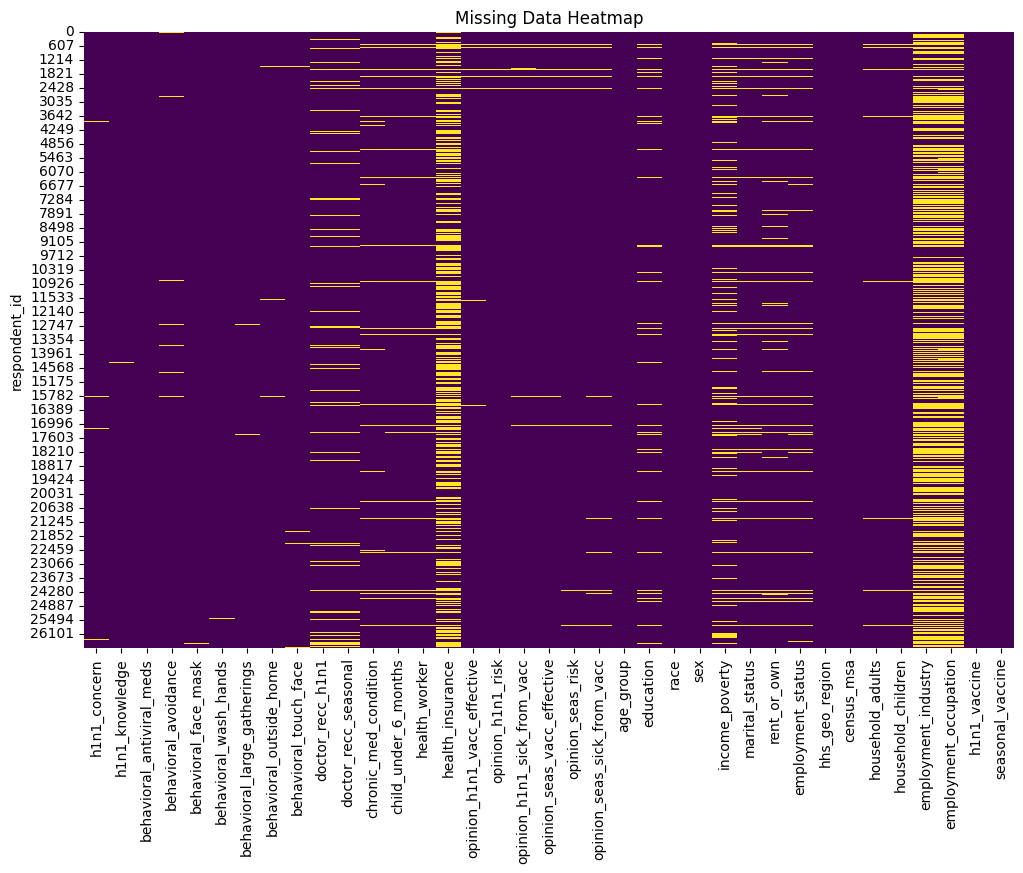

In [125]:
plt.figure(figsize=(12, 8))

# Missing Data Heatmap
sns.heatmap(new_merged.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [126]:
new_merged.isna().sum()

,0
h1n1_concern,92
h1n1_knowledge,116
behavioral_antiviral_meds,71
behavioral_avoidance,208
behavioral_face_mask,19
behavioral_wash_hands,42
behavioral_large_gatherings,87
behavioral_outside_home,82
behavioral_touch_face,128
doctor_recc_h1n1,2160


In [127]:
new_merged.duplicated().sum()

np.int64(0)

### Correlation — Numeric Features vs Targets

#### We check the correlation between the numerical features and target variables.

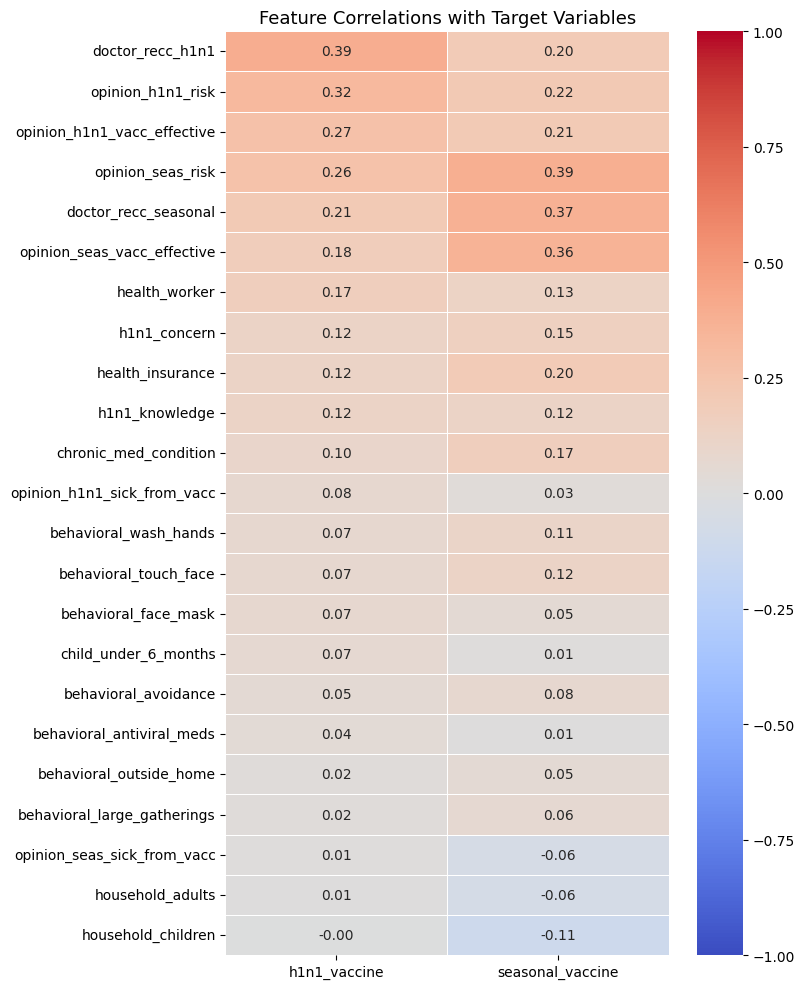

In [128]:
num_df = new_merged.select_dtypes(include='number')
corr_with_targets = num_df.corr()[['h1n1_vaccine', 'seasonal_vaccine']].drop(
    ['h1n1_vaccine', 'seasonal_vaccine']
).sort_values('h1n1_vaccine', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_targets, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlations with Target Variables', fontsize=13)
plt.tight_layout()
plt.show()

### Categorical Features — Vaccine Uptake by Group

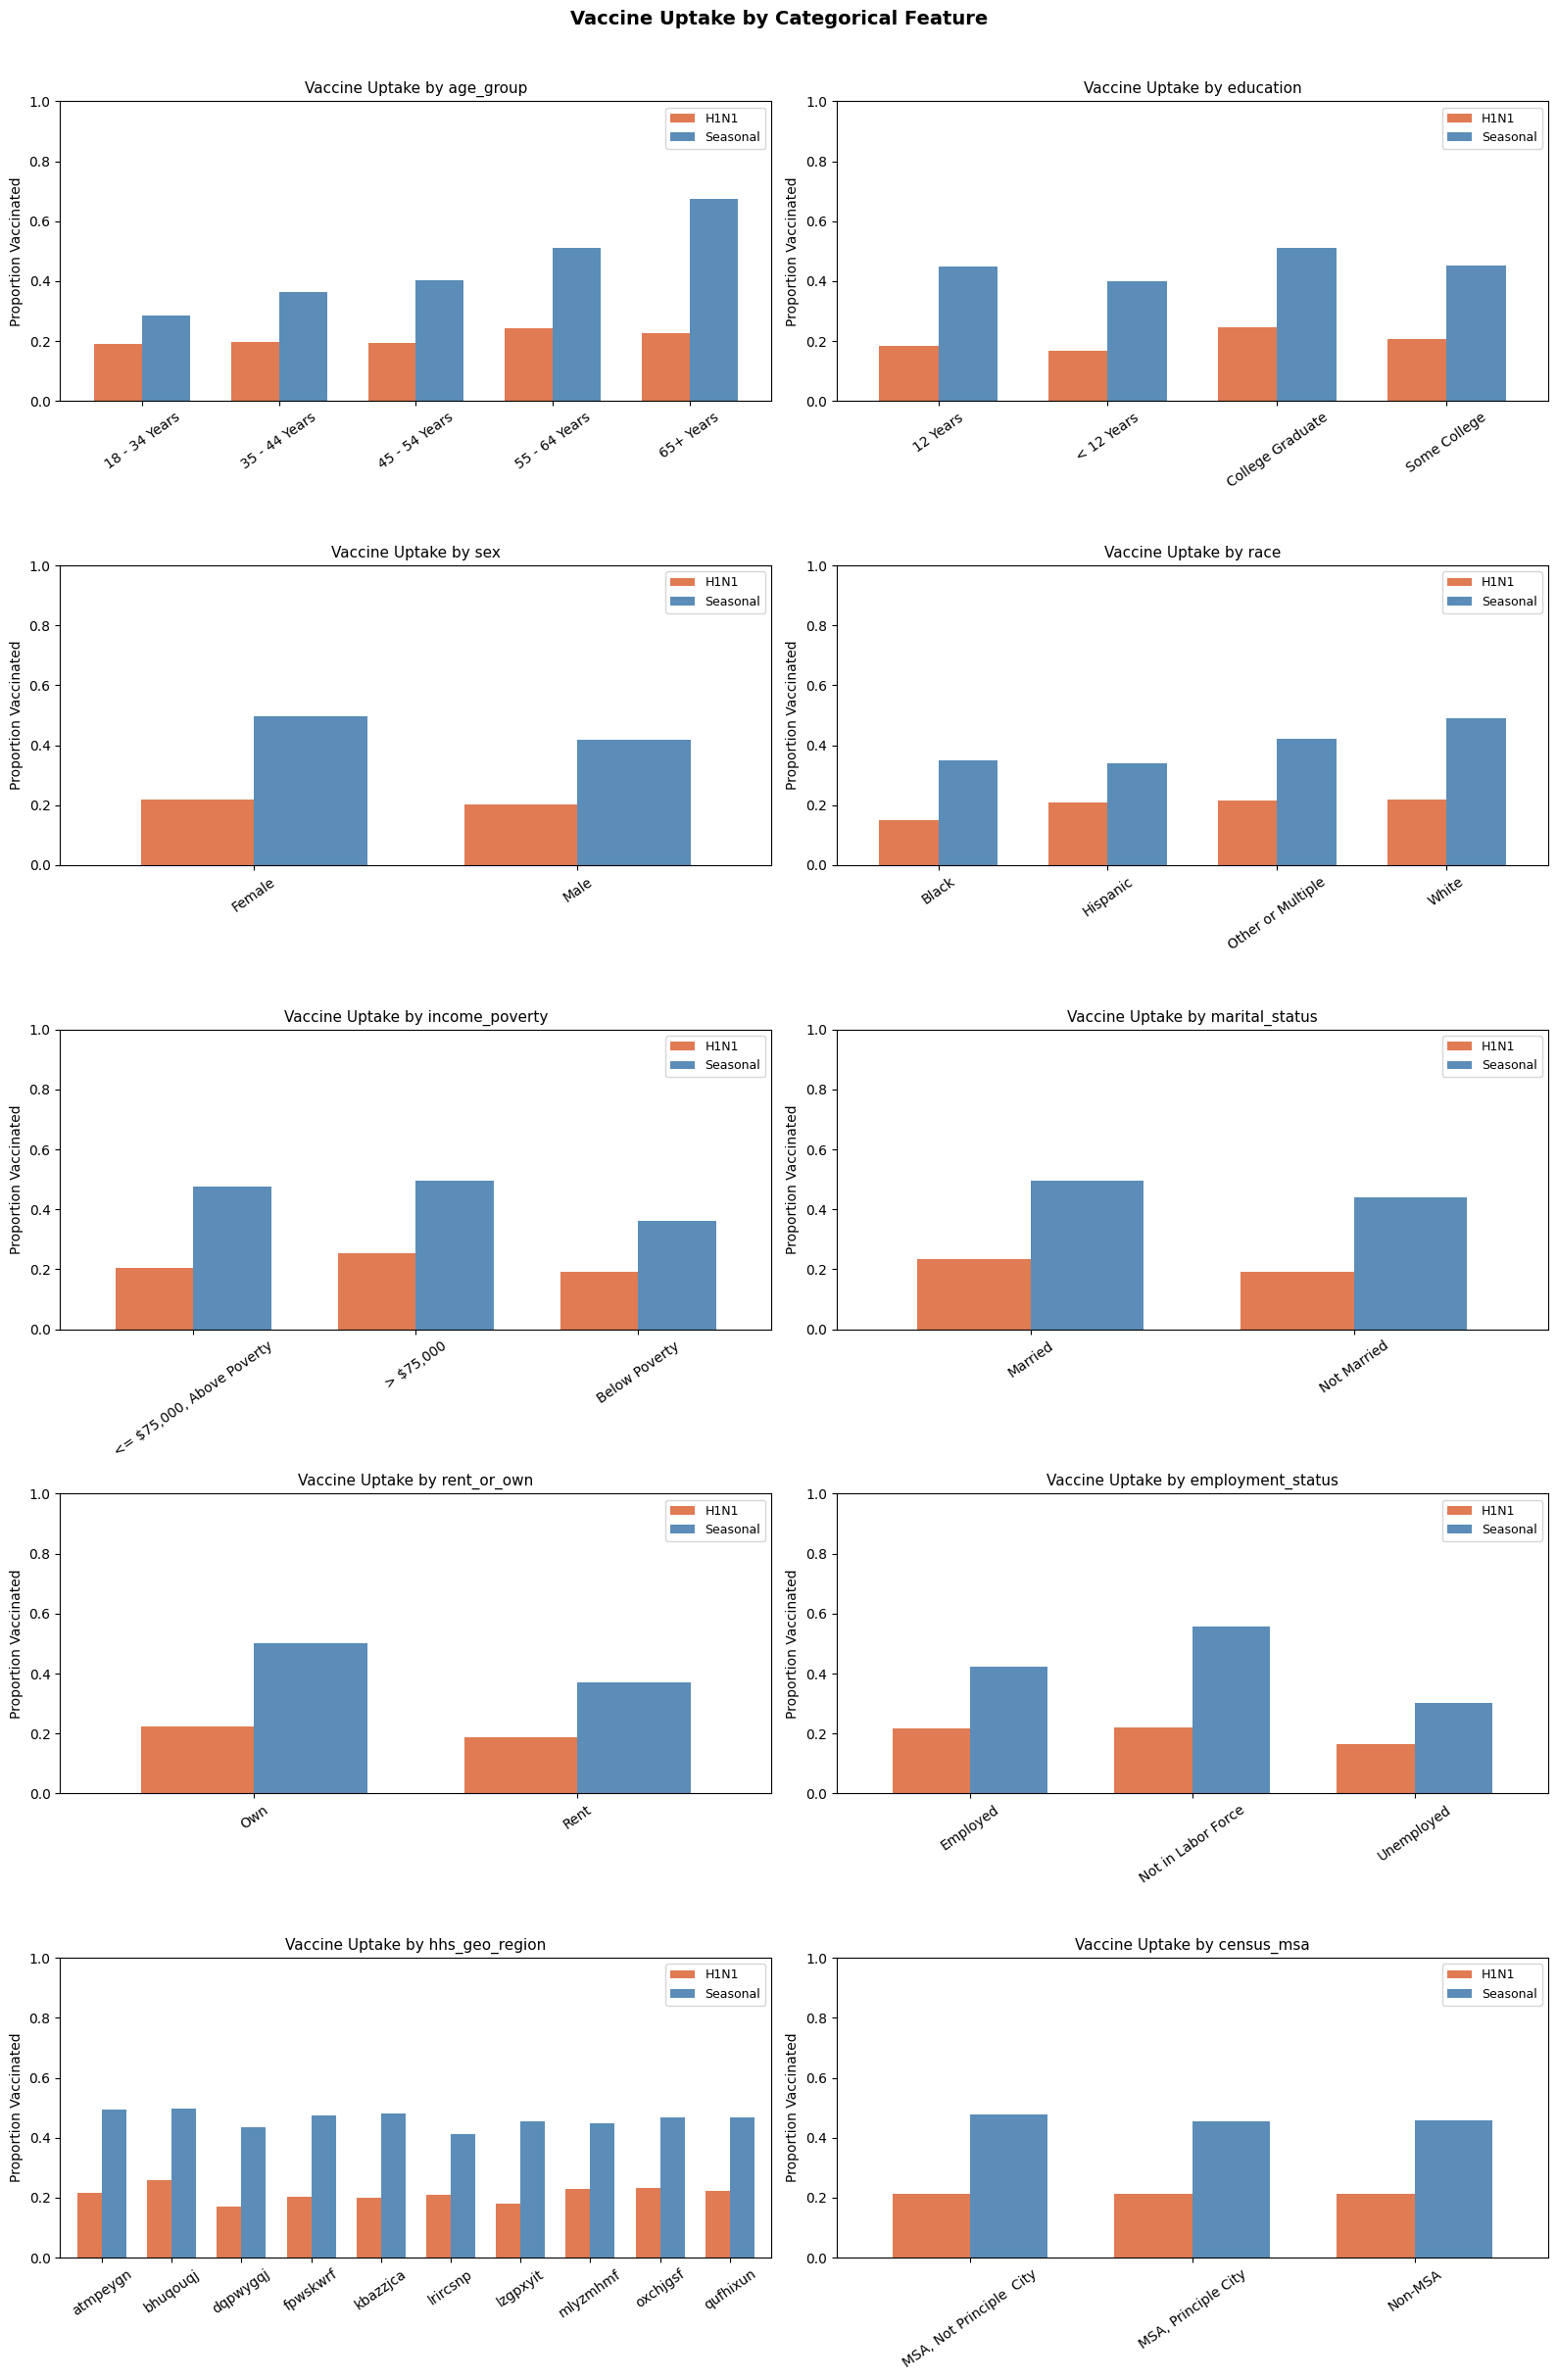

In [129]:
cat_features = [
    'age_group', 'education', 'sex', 'race',
    'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'hhs_geo_region', 'census_msa'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    uptake = new_merged.groupby(col)[['h1n1_vaccine', 'seasonal_vaccine']].mean()
    uptake.plot(kind='bar', ax=axes[i], color=['#e07b54', '#5b8db8'], width=0.7)
    axes[i].set_title(f'Vaccine Uptake by {col}', fontsize=11)
    axes[i].set_ylabel('Proportion Vaccinated')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['H1N1', 'Seasonal'], fontsize=9)
    axes[i].set_ylim(0, 1)

plt.suptitle('Vaccine Uptake by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### GROUPING WHO GOT EITHER VACCINES, NONE, OR BOTH

In [130]:
def vaccine_group(row):
    if row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 1:
        return 'Both Vaccines'
    elif row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 0:
        return 'H1N1 Only'
    elif row['h1n1_vaccine'] == 0 and row['seasonal_vaccine'] == 1:
        return 'Seasonal Only'
    else:
        return 'Neither Vaccine'
new_merged['vaccine_group'] = new_merged.apply(vaccine_group, axis=1)

In [131]:
# Count and percentage
group_counts = new_merged['vaccine_group'].value_counts()
group_pct    = (group_counts / len(new_merged) * 100).round(1)
print(pd.DataFrame({'Count': group_counts, '%': group_pct}))

                 Count     %
vaccine_group               
Neither Vaccine  13295  49.8
Seasonal Only     7738  29.0
Both Vaccines     4697  17.6
H1N1 Only          977   3.7


### Defining my X and Y variables

#### Feature Engineering

Dropping new formed column, vaccine_group, in X, to avoid Data Leakage.

In [132]:


X = new_merged.drop(columns=['h1n1_vaccine', 'seasonal_vaccine','vaccine_group'])

y = new_merged[['h1n1_vaccine', 'seasonal_vaccine']]

### SPLITTING MY DATA

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [134]:
X_train.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",1.0,0.0,NaN,NaN
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",0.0,0.0,wxleyezf,emcorrxb
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,NaN,Married,NaN,Employed,qufhixun,"MSA, Not Principle City",1.0,1.0,xicduogh,xtkaffoo
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,Not Married,Own,Employed,bhuqouqj,Non-MSA,0.0,0.0,cfqqtusy,ukymxvdu
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",1.0,1.0,NaN,NaN


In [135]:
y_train.head()

,h1n1_vaccine,seasonal_vaccine
respondent_id,,
24706,0,0
5393,0,1
20898,1,1
3429,0,0
8731,0,0


In [136]:
X_test.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,atmpeygn,"MSA, Principle City",NaN,NaN,NaN,NaN
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,fpwskwrf,"MSA, Principle City",1.0,1.0,NaN,NaN
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,NaN,Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",0.0,1.0,mfikgejo,mxkfnird
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"> $75,000",Married,Own,Employed,bhuqouqj,Non-MSA,1.0,2.0,cfqqtusy,xtkaffoo
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,"> $75,000",Married,Own,Employed,lrircsnp,"MSA, Principle City",1.0,0.0,wxleyezf,xtkaffoo


#### EXPLORING MY SPLIT DATA

#### FOR X_TRAIN

In [137]:
X_train.info()



<class 'pandas.core.frame.DataFrame'>
Index: 21365 entries, 24706 to 23654
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 21292 non-null  float64
 1   h1n1_knowledge               21274 non-null  float64
 2   behavioral_antiviral_meds    21306 non-null  float64
 3   behavioral_avoidance         21202 non-null  float64
 4   behavioral_face_mask         21351 non-null  float64
 5   behavioral_wash_hands        21329 non-null  float64
 6   behavioral_large_gatherings  21293 non-null  float64
 7   behavioral_outside_home      21306 non-null  float64
 8   behavioral_touch_face        21263 non-null  float64
 9   doctor_recc_h1n1             19629 non-null  float64
 10  doctor_recc_seasonal         19629 non-null  float64
 11  chronic_med_condition        20594 non-null  float64
 12  child_under_6_months         20710 non-null  float64
 13  health_worker    

In [138]:
X_train.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [139]:
X_train.shape

(21365, 35)

In [140]:
X_train.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,21292.000000,21274.000000,21306.000000,21202.000000,21351.000000,21329.000000,21293.000000,21306.000000,21263.000000,19629.000000,...,20722.000000,11507.000000,21047.000000,21054.000000,21044.000000,20994.000000,20955.000000,20934.000000,21163.000000,21163.000000
mean,1.618026,1.265018,0.049329,0.724507,0.070348,0.823574,0.357864,0.337464,0.675728,0.221662,...,0.113840,0.879465,3.848910,2.345730,2.361196,4.029532,2.722023,2.121286,0.888910,0.535888
std,0.909311,0.617816,0.216559,0.446773,0.255739,0.381192,0.479383,0.472856,0.468113,0.415375,...,0.317625,0.325601,1.008976,1.287865,1.362904,1.082279,1.385780,1.335174,0.754466,0.929504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [141]:
X_train.isna().sum()

,0
h1n1_concern,73
h1n1_knowledge,91
behavioral_antiviral_meds,59
behavioral_avoidance,163
behavioral_face_mask,14
behavioral_wash_hands,36
behavioral_large_gatherings,72
behavioral_outside_home,59
behavioral_touch_face,102
doctor_recc_h1n1,1736


In [142]:
X_train.duplicated().sum()

np.int64(0)

#### FOR X_TEST

In [143]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5342 entries, 15772 to 12943
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 5323 non-null   float64
 1   h1n1_knowledge               5317 non-null   float64
 2   behavioral_antiviral_meds    5330 non-null   float64
 3   behavioral_avoidance         5297 non-null   float64
 4   behavioral_face_mask         5337 non-null   float64
 5   behavioral_wash_hands        5336 non-null   float64
 6   behavioral_large_gatherings  5327 non-null   float64
 7   behavioral_outside_home      5319 non-null   float64
 8   behavioral_touch_face        5316 non-null   float64
 9   doctor_recc_h1n1             4918 non-null   float64
 10  doctor_recc_seasonal         4918 non-null   float64
 11  chronic_med_condition        5142 non-null   float64
 12  child_under_6_months         5177 non-null   float64
 13  health_worker     

In [144]:
X_test.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [145]:
X_test.shape

(5342, 35)

In [146]:
X_test.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,5323.000000,5317.000000,5330.000000,5297.000000,5337.000000,5336.000000,5327.000000,5319.000000,5316.000000,4918.000000,...,5181.000000,2926.000000,5269.000000,5265.000000,5268.000000,5251.000000,5238.000000,5236.000000,5295.000000,5295.000000
mean,1.620327,1.252586,0.046904,0.730036,0.063519,0.833771,0.361742,0.336717,0.683409,0.214925,...,0.104227,0.880725,3.857468,2.329915,2.343584,4.011807,2.707713,2.105424,0.876865,0.529367
std,0.914381,0.619439,0.211454,0.443983,0.243917,0.372321,0.480550,0.472632,0.465190,0.410812,...,0.305584,0.324168,1.001324,1.276240,1.362251,1.103524,1.382224,1.324070,0.749224,0.922905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [147]:
X_test.isna().sum()

,0
h1n1_concern,19
h1n1_knowledge,25
behavioral_antiviral_meds,12
behavioral_avoidance,45
behavioral_face_mask,5
behavioral_wash_hands,6
behavioral_large_gatherings,15
behavioral_outside_home,23
behavioral_touch_face,26
doctor_recc_h1n1,424


In [148]:
X_test.duplicated().sum()

np.int64(0)

## DATA CLEANING AND PREPROCESSING

#### 1. Dropping unnecessary columns

In [149]:

new_X_train = X_train.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_train.head()


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
respondent_id,,,,,,,,,,,,,,,,,,,,,
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Some College,White,Female,Below Poverty,Married,Rent,Unemployed,"MSA, Not Principle City",1.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,White,Male,"> $75,000",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,NaN,White,Male,NaN,Married,NaN,Employed,"MSA, Not Principle City",1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,Other or Multiple,Female,NaN,Not Married,Own,Employed,Non-MSA,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",1.0,1.0


In [150]:
new_X_test = X_test.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_test.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
respondent_id,,,,,,,,,,,,,,,,,,,,,
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,White,Female,NaN,NaN,NaN,NaN,"MSA, Principle City",NaN,NaN
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,...,NaN,White,Male,NaN,NaN,NaN,NaN,"MSA, Principle City",1.0,1.0
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,White,Female,NaN,Not Married,Own,Employed,"MSA, Not Principle City",0.0,1.0
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,White,Female,"> $75,000",Married,Own,Employed,Non-MSA,1.0,2.0
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,White,Male,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0


#### 2. FILLING MISSING VALUES

##### Filling Missing values for X_train

## Create copies of dataset
### We create copies , in order not to make permernent changes to our initial dataset.

In [151]:
#Filling Missing values for X_train
numerical_columns = new_X_train.select_dtypes(include='number').columns.tolist()
numerical_columns

['h1n1_concern',
 'h1n1_knowledge',
 'behavioral_antiviral_meds',
 'behavioral_avoidance',
 'behavioral_face_mask',
 'behavioral_wash_hands',
 'behavioral_large_gatherings',
 'behavioral_outside_home',
 'behavioral_touch_face',
 'doctor_recc_h1n1',
 'doctor_recc_seasonal',
 'chronic_med_condition',
 'child_under_6_months',
 'health_worker',
 'health_insurance',
 'opinion_h1n1_vacc_effective',
 'opinion_h1n1_risk',
 'opinion_h1n1_sick_from_vacc',
 'opinion_seas_vacc_effective',
 'opinion_seas_risk',
 'opinion_seas_sick_from_vacc',
 'household_adults',
 'household_children']

In [152]:
categorical_columns = new_X_train.select_dtypes(include='object').columns.tolist()

categorical_columns

['age_group',
 'education',
 'race',
 'sex',
 'income_poverty',
 'marital_status',
 'rent_or_own',
 'employment_status',
 'census_msa']

In [153]:
numerical_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_clean = X_train.copy()
X_train_clean_num = pd.DataFrame(numerical_imputer.fit_transform(X_train_clean[numerical_columns]), columns=numerical_columns, index=X_train_clean.index)
X_train_clean_cat = pd.DataFrame(categorical_imputer.fit_transform(X_train_clean[categorical_columns]), columns=categorical_columns, index=X_train_clean.index)

# X_train_num = pd.DataFrame(numerical_imputer.fit_transform(X_train_clean[numerical_columns]), columns=numerical_columns, index=X_train_clean.index)
# X_train_cat = pd.DataFrame(categorical_imputer.fit_transform(X_train_clean[categorical_columns]), columns=categorical_columns, index=X_train_clean.index)

##### Filling Missing values for X_test

In [154]:
X_test_clean = X_test.copy()
X_test_clean_num = pd.DataFrame(numerical_imputer.transform(X_test_clean[numerical_columns]), columns=numerical_columns, index=X_test_clean.index)
X_test_clean_cat= pd.DataFrame(categorical_imputer.transform(X_test_clean[categorical_columns]), columns=categorical_columns, index=X_test_clean.index)

# X_test_num = pd.DataFrame(numerical_imputer.transform(X_test_clean[numerical_columns]), columns=numerical_columns, index=X_test_clean.index)
# X_test_cat= pd.DataFrame(categorical_imputer.transform(X_test_clean[categorical_columns]), columns=categorical_columns, index=X_test_clean.index)


#### 3. Checking For Outliers
The numeric features in this dataset are either binary,0 or 1,or ordinal scales,1–5. Because the values are bounded, any extreme responses are still valid answers and not errors. The models to be used are also not heavily affected by outliers. No rows removed.

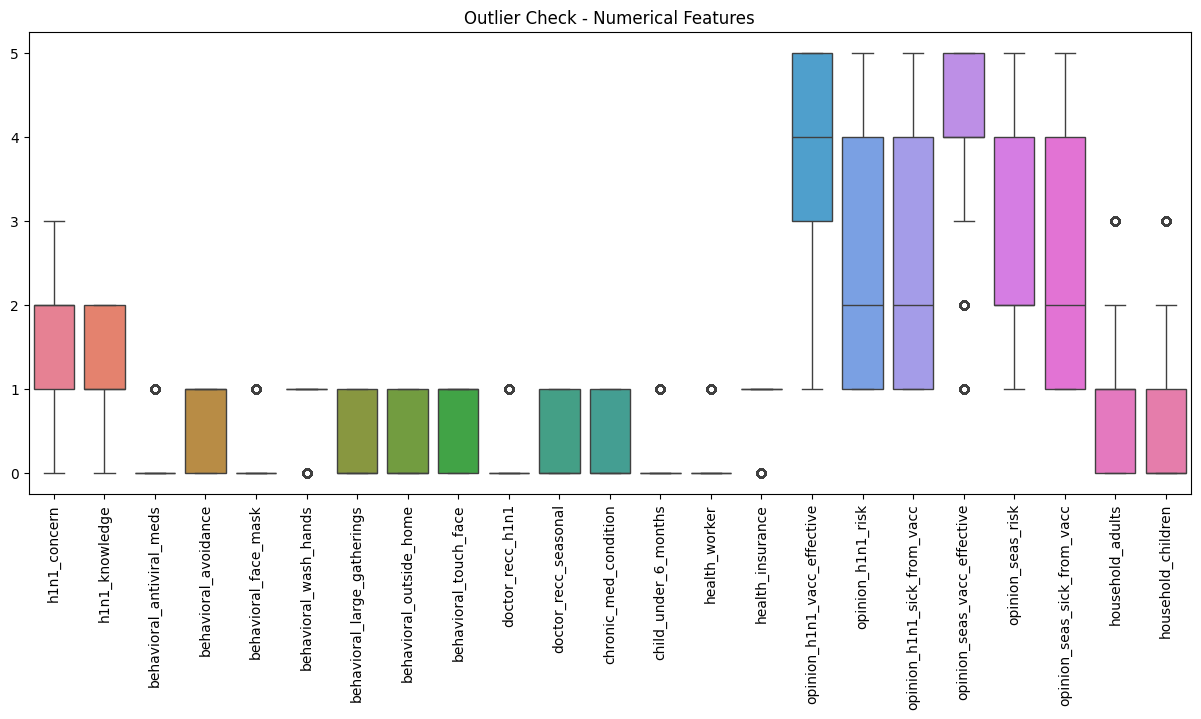

In [155]:
plt.figure(figsize=(15,6))
sns.boxplot(data=X_train[numerical_columns])
plt.xticks(rotation=90)
plt.title("Outlier Check - Numerical Features")
plt.show()

The boxplots reveal the presence of some outliers across numerical features, but they are not overly extreme or widespread. These values are retained as they may represent genuine variations rather than errors and are unlikely to significantly distort the models.

### EXPLORATORY DATA ANALYSIS- PART 2

#### 1. UNIVARIATE ANALYSIS

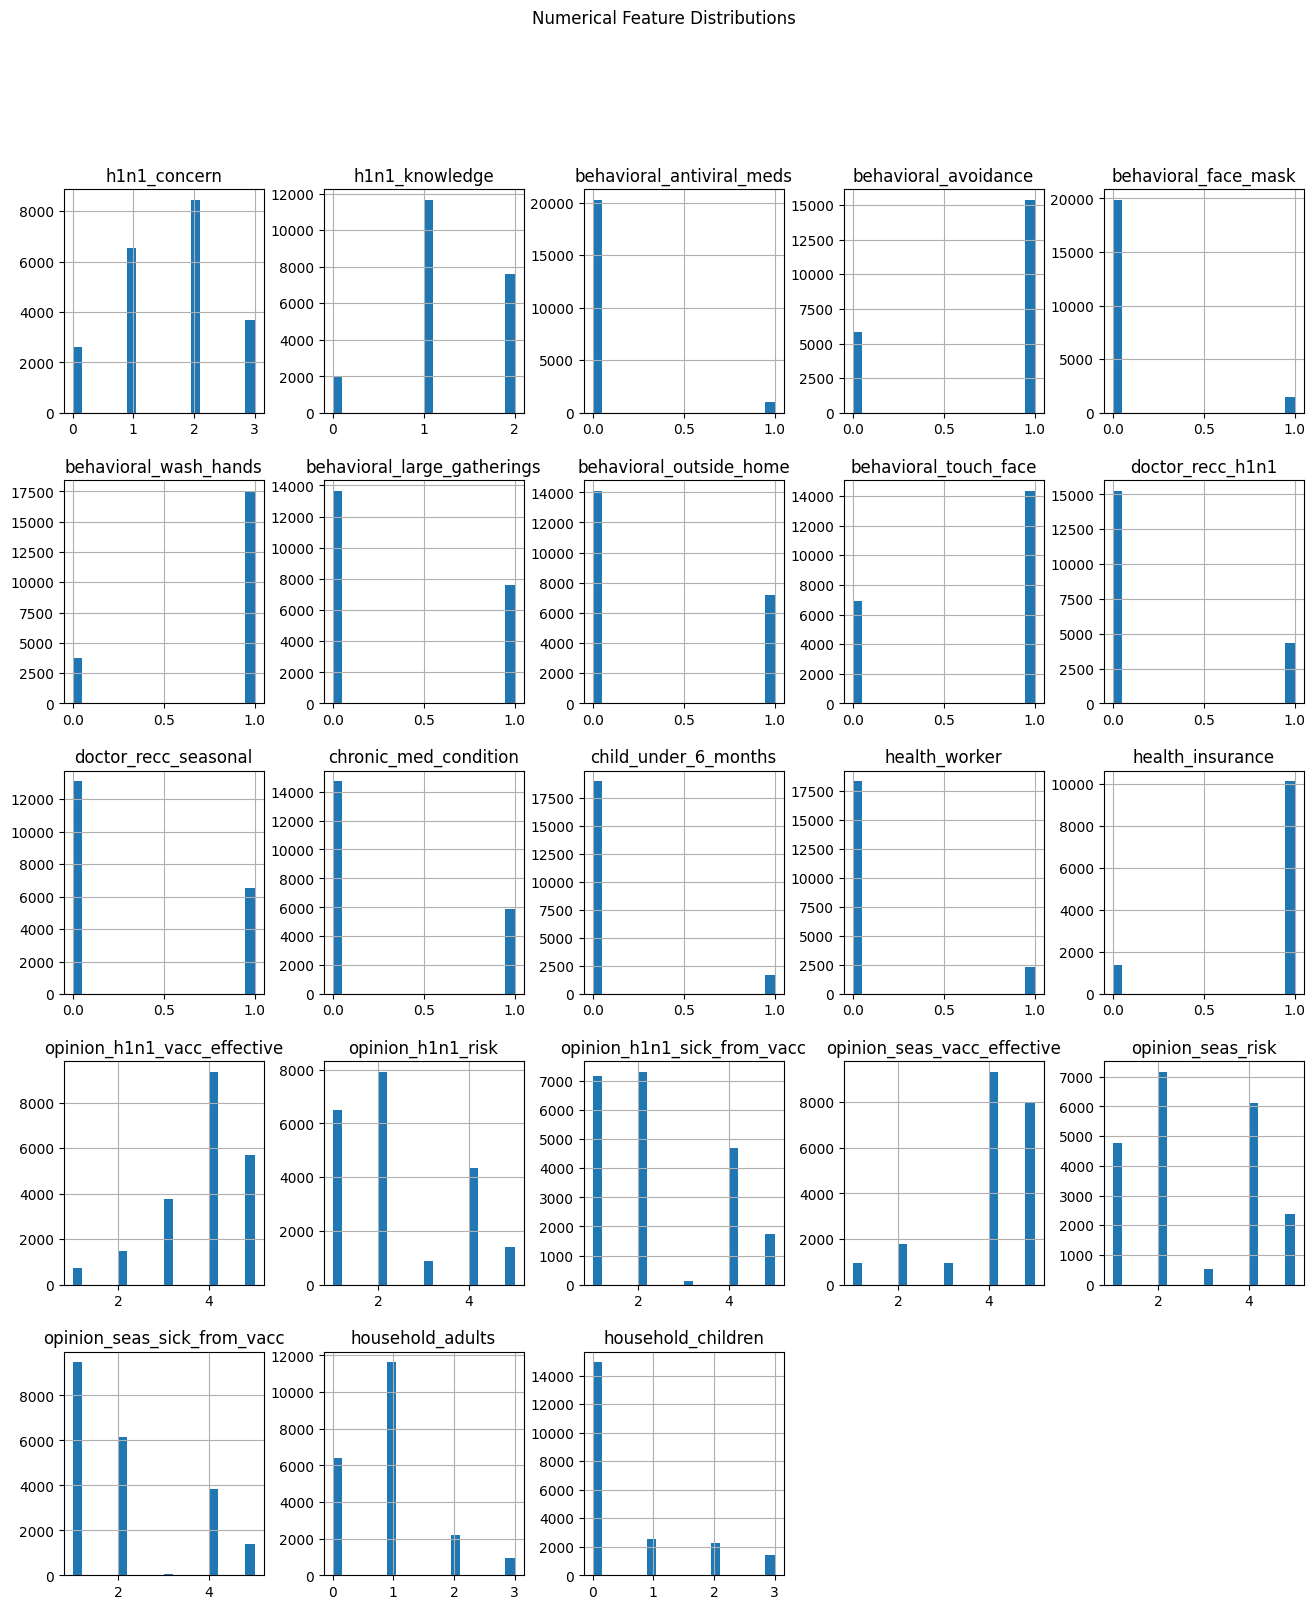

In [156]:
#NUMERICAL FEATURES
X_train[numerical_columns].hist(figsize=(16,18), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [157]:
#CATEGORICAL FEATURES
for col in categorical_columns:
    print(f"\n{col}")
    print(X_train[col].value_counts(normalize=True).head())


age_group
age_group
65+ Years        0.255277
55 - 64 Years    0.208799
18 - 34 Years    0.197145
45 - 54 Years    0.195834
35 - 44 Years    0.142944
Name: proportion, dtype: float64

education
education
College Graduate    0.398370
Some College        0.279941
12 Years            0.229051
< 12 Years          0.092638
Name: proportion, dtype: float64

race
race
White                0.794477
Black                0.077510
Hispanic             0.066136
Other or Multiple    0.061877
Name: proportion, dtype: float64

sex
sex
Female    0.596677
Male      0.403323
Name: proportion, dtype: float64

income_poverty
income_poverty
<= $75,000, Above Poverty    0.577055
> $75,000                    0.303905
Below Poverty                0.119041
Name: proportion, dtype: float64

marital_status
marital_status
Married        0.537417
Not Married    0.462583
Name: proportion, dtype: float64

rent_or_own
rent_or_own
Own     0.760602
Rent    0.239398
Name: proportion, dtype: float64

employment_status
e

The univariate analysis shows that several numerical features are skewed, while categorical variables are often imbalanced with dominant categories. This highlights the need for proper preprocessing before modeling.

#### 2. BIVARIATE ANALYSIS- TARGET VS FEATURES
a) Numerical vs Target

In [158]:
for col in categorical_columns:
    cross_tab = pd.crosstab(X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.811491  0.188509
35 - 44 Years  0.802554  0.197446
45 - 54 Years  0.803537  0.196463
55 - 64 Years  0.759247  0.240753
65+ Years      0.770627  0.229373

education
h1n1_vaccine             0         1
education                           
12 Years          0.816437  0.183563
< 12 Years        0.837867  0.162133
College Graduate  0.754062  0.245938
Some College      0.788387  0.211613

race
h1n1_vaccine              0         1
race                                 
Black              0.847826  0.152174
Hispanic           0.799009  0.200991
Other or Multiple  0.788956  0.211044
White              0.780311  0.219689

sex
h1n1_vaccine         0         1
sex                             
Female        0.781064  0.218936
Male          0.796565  0.203435

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.794195  0.

b) Categorical vs Target

In [159]:
for col in categorical_columns:
    cross_tab = pd.crosstab(X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.811491  0.188509
35 - 44 Years  0.802554  0.197446
45 - 54 Years  0.803537  0.196463
55 - 64 Years  0.759247  0.240753
65+ Years      0.770627  0.229373

education
h1n1_vaccine             0         1
education                           
12 Years          0.816437  0.183563
< 12 Years        0.837867  0.162133
College Graduate  0.754062  0.245938
Some College      0.788387  0.211613

race
h1n1_vaccine              0         1
race                                 
Black              0.847826  0.152174
Hispanic           0.799009  0.200991
Other or Multiple  0.788956  0.211044
White              0.780311  0.219689

sex
h1n1_vaccine         0         1
sex                             
Female        0.781064  0.218936
Male          0.796565  0.203435

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.794195  0.

The bivariate analysis indicates clear relationships between features and the target variables, suggesting that both demographic and behavioral factors influence vaccination outcomes and will be useful for prediction.

## PRE-PROCESSING

### ENCODING CATEGORICAL COLUMNS

In [160]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train_clean_cat), columns=ohe.get_feature_names_out(categorical_columns), index=X_train_clean.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test_clean_cat), columns=ohe.get_feature_names_out(categorical_columns), index=X_test_clean.index)


#### CONCATINATION

In [161]:
Final_X_train = pd.concat([X_train_clean_num, X_train_ohe], axis=1)
Final_X_test = pd.concat([X_test_clean_num, X_test_ohe], axis=1)

## MODELLING


We employ a 4-stage iterative modeling approach to benchmark algorithmic performance:

| Model | Purpose |
| :--- | :--- |
| **1. Baseline Logistic Regression** | Establish a fast, interpretable benchmark for vaccine uptake. |
| **2. SMOTE Logistic Regression** | Prioritize **Class 1 Recall** to better identify vaccinated individuals. |
| **3. Decision Tree** | Explore non-linear relationships and interactions. |
| **4. Random Forest (Tuned)** | Optimize performance and improve generalizability via ensemble learning. |

**Primary metric:** ROC-AUC (ranges 0.5–1.0; higher is better) and **Recall** (prioritizing detection of vaccinated classes).

# MODEL 1

### 1. Baseline — Logistic Regression

In [179]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(Final_X_train)
X_test_scaled = scaler.transform(Final_X_test)

lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)


# Define the baseline model
base_lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))

# Train it on the training data
base_lr.fit(X_train_scaled, y_train)


MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000,
                                                   random_state=42))

#### CROSS VALIDATION

In [176]:
# H1N1
cv_h1n1 = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train['h1n1_vaccine'],
    cv=5,
    scoring='accuracy'
)

# Seasonal
cv_seasonal = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train['seasonal_vaccine'],
    cv=5,
    scoring='accuracy'
)

print("CV H1N1 Accuracy:", cv_h1n1.mean())
print("CV Seasonal Accuracy:", cv_seasonal.mean())

CV H1N1 Accuracy: 0.8343084483969108
CV Seasonal Accuracy: 0.7736484905218816


ACCURACY SCORE FOR EACH TARGET VARIABLE


In [178]:
print("H1N1 Accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_pred[:,0]))
print("Seasonal Accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_pred[:,1]))

H1N1 Accuracy: 0.8423811306626732
Seasonal Accuracy: 0.7832272557094722


## Interpretation of my accuracy results
1.) H1N Accuracy - Out of all the thousands of patients in the test data, my Logistic Regression model looked at the urveys and correctly predicted whether they got the H1N1 vaccine or not 82.8% of the time.

2.) Seasonal Accuracy - Just like the H1N1 score, my your model looked at thousands of new test patients it had never seen before, checked out their survey answers, and successfully predicted their Seasonal vaccine status 76.17% of the time.

### MODEL 1 EVALUATION (BASELINE)

a) CLASSIFICATION REPORT

In [181]:
print("=== Logistic Regression: H1N1 ===")
print(classification_report(y_test['h1n1_vaccine'], y_pred[:,0]))

print("\n=== Logistic Regression: Seasonal ===")
print(classification_report(y_test['seasonal_vaccine'], y_pred[:,1]))

=== Logistic Regression: H1N1 ===
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      4212
           1       0.71      0.43      0.54      1130

    accuracy                           0.84      5342
   macro avg       0.79      0.69      0.72      5342
weighted avg       0.83      0.84      0.83      5342


=== Logistic Regression: Seasonal ===
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2891
           1       0.77      0.74      0.76      2451

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



### CLASSIFICATION REPORT SUMMARY

1. H1N1

Precision for Class 0 (Not Vaccinated) = 0.86: When the model predicted an individual did not receive the H1N1 vaccine, it was correct 86% of the time.

Recall for Class 0 (Not Vaccinated) = 0.95: The model correctly identified 95% of all individuals who did not receive the vaccine, indicating strong performance for the majority class.

Precision for Class 1 (Vaccinated) = 0.71: When the model predicted an individual received the H1N1 vaccine, it was correct 71% of the time.

Recall for Class 1 (Vaccinated) = 0.43: The model correctly identified only 43% of vaccinated individuals, showing difficulty in capturing the minority class.

F1-score for Class 0 = 0.91: This indicates a strong balance between precision and recall for non-vaccinated individuals.

F1-score for Class 1 = 0.54: This relatively low score highlights that the model struggles to effectively detect vaccinated individuals.

Conclusion: The model performs well in identifying non-vaccinated individuals but has low recall for vaccinated individuals, suggesting class imbalance and the need for improvement (e.g., SMOTE).



2. Seasonal
Precision for Class 0 (Not Vaccinated) = 0.79: When predicting non-vaccinated individuals, the model was correct 79% of the time.

Recall for Class 0 (Not Vaccinated) = 0.82: The model correctly identifies 82% of all non-vaccinated individuals.

Precision for Class 1 (Vaccinated) = 0.77: When predicting vaccinated individuals, the model was correct 77% of the time.

Recall for Class 1 (Vaccinated) = 0.74: The model correctly identifies 74% of vaccinated individuals, showing balanced performance.

F1-score for Class 0 = 0.80: Indicates good balance in identifying non-vaccinated individuals.

F1-score for Class 1 = 0.76: Shows relatively strong performance in identifying vaccinated individuals compared to H1N1.

Conclusion: The model performs fairly well and balanced for seasonal vaccine prediction, with no major class imbalance issues compared to H1N1.

b) ROC-AUC SCORE

In [182]:
y_prob_lr = lr.predict_proba(X_test_scaled)

h1n1_probs = y_prob_lr[0][:,1]
seasonal_probs = y_prob_lr[1][:,1]

print("H1N1 ROC AUC:", roc_auc_score(y_test['h1n1_vaccine'], h1n1_probs))
print("Seasonal ROC AUC:", roc_auc_score(y_test['seasonal_vaccine'], seasonal_probs))

H1N1 ROC AUC: 0.8275851129095967
Seasonal ROC AUC: 0.8520857298378556


ROC CURVE

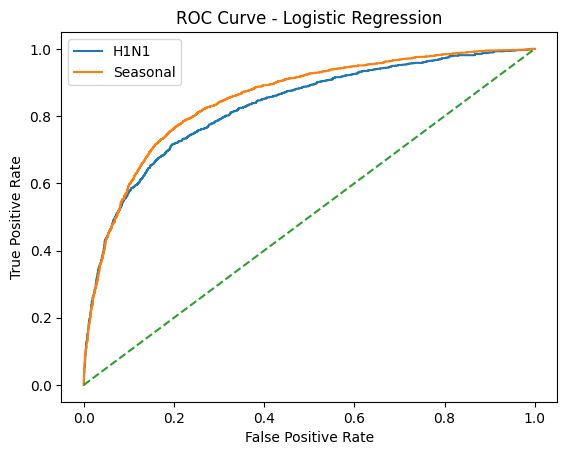

In [183]:
# H1N1
fpr1, tpr1, _ = roc_curve(y_test['h1n1_vaccine'], h1n1_probs)

# Seasonal
fpr2, tpr2, _ = roc_curve(y_test['seasonal_vaccine'], seasonal_probs)

plt.figure()

plt.plot(fpr1, tpr1, label="H1N1")
plt.plot(fpr2, tpr2, label="Seasonal")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

### CONCLUSION
The Logistic Regression is my baseline model. Cross-validation results show consistent performance across folds, indicating stability. The model achieves moderate accuracy for both H1N1 and seasonal vaccine predictions. However, the classification report reveals lower recall for the minority class, suggesting difficulty in identifying vaccinated individuals. ROC-AUC scores indicates reasonable discrimination ability, but overall performance suggests that more complex models may be required for improved predictive accuracy.

## CHECKING FOR CLASS IMBALANCE IN MY DATA

Happens when one class appears more often than the other in a dataset.
A model built on imbalanced datasets tends to be lazy and always predicts the majority class.

In [184]:
# 1. Check the H1N1 Vaccine percentages
print("H1N1 Vaccine Split:")
print(y_train['h1n1_vaccine'].value_counts(normalize=True))

# 2. Check the Seasonal Vaccine percentages
print("\nSeasonal Vaccine Split:")
print(y_train['seasonal_vaccine'].value_counts(normalize=True))


 # 3. Check the value counts
print(y_train['h1n1_vaccine'].value_counts())
print(y_train['seasonal_vaccine'].value_counts())



H1N1 Vaccine Split:
h1n1_vaccine
0    0.787316
1    0.212684
Name: proportion, dtype: float64

Seasonal Vaccine Split:
seasonal_vaccine
0    0.532694
1    0.467306
Name: proportion, dtype: float64
h1n1_vaccine
0    16821
1     4544
Name: count, dtype: int64
seasonal_vaccine
0    11381
1     9984
Name: count, dtype: int64


Presence of class imbalance in H1N1 vaccine data.Class 0 has 78% and class 1 has 22%, with class 0 having the majority by a higher percentage.  Built models with this imbalance will tend to make my predictions lazy, by them predicting the majority class.

My seasonal vaccine data is almost balanced, with class 0 having 54% and class 1 having 46%. There is no need to remove imbalance in seasonal vaccine data.

### HANDLING IMBALANCED DATASET USING SMOTE

 Steps in Synthetic Minority Oversampling Technique:

    - Pick a minority point

    - Find its nearest neighbors

    - Create a new point between them


In [185]:

# 1. Handling Imbalanced for H1N1 Vaccine
y_train_h1n1 = y_train['h1n1_vaccine']

# 2. Balance the features and the target instantly
smote = SMOTE(random_state=42)
X_train_h1n1_smoted, y_train_h1n1_smoted = smote.fit_resample(X_train_scaled, y_train_h1n1)

# 3. Print the new balanced counts
print("New H1N1 Counts After SMOTE:\n", pd.Series(y_train_h1n1_smoted).value_counts())


New H1N1 Counts After SMOTE:
 h1n1_vaccine
0    16821
1    16821
Name: count, dtype: int64


# MODEL 2

### BUILDING SMOTE MODEL

In [189]:

smote = SMOTE(random_state=42)

# H1N1
X_smote_h1n1, y_smote_h1n1 = smote.fit_resample(
    X_train_scaled, y_train['h1n1_vaccine']
)

# Seasonal
X_smote_seasonal, y_smote_seasonal = smote.fit_resample(
    X_train_scaled, y_train['seasonal_vaccine']
)

#Training the model
lr_h1n1 = LogisticRegression(max_iter=1000, random_state=42)
lr_seasonal = LogisticRegression(max_iter=1000, random_state=42)

lr_h1n1.fit(X_smote_h1n1, y_smote_h1n1)
lr_seasonal.fit(X_smote_seasonal, y_smote_seasonal)


# Predictions
h1n1_pred_smote = lr_h1n1.predict(X_test_scaled)
seasonal_pred_smote = lr_seasonal.predict(X_test_scaled)

CROSS VALIDATION

In [190]:
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

# H1N1
cv_h1n1_smote = cross_val_score(
    pipeline,
    X_train_scaled,
    y_train['h1n1_vaccine'],
    cv=5,
    scoring='accuracy'
)

# Seasonal
cv_seasonal_smote = cross_val_score(
    pipeline,
    X_train_scaled,
    y_train['seasonal_vaccine'],
    cv=5,
    scoring='accuracy'
)

print("SMOTE CV H1N1:", cv_h1n1_smote.mean())
print("SMOTE CV Seasonal:", cv_seasonal_smote.mean())

SMOTE CV H1N1: 0.7758483501053124
SMOTE CV Seasonal: 0.7745377954598642


ACCURACY SCORE FOR EACH TARGET VARIABLE

In [191]:
print("H1N1 Accuracy (SMOTE):", accuracy_score(y_test['h1n1_vaccine'], h1n1_pred_smote))
print("Seasonal Accuracy (SMOTE):", accuracy_score(y_test['seasonal_vaccine'], seasonal_pred_smote))


H1N1 Accuracy (SMOTE): 0.7770497940846125
Seasonal Accuracy (SMOTE): 0.7830400599026581


### MODEL 2 EVALUATION (SMOTE)

a) CLASSIFICATION REPORT

In [192]:
print("\n=== SMOTE Logistic Regression: H1N1 ===")
print(classification_report(y_test['h1n1_vaccine'], h1n1_pred_smote))

print("\n=== SMOTE Logistic Regression: Seasonal ===")
print(classification_report(y_test['seasonal_vaccine'], seasonal_pred_smote))



=== SMOTE Logistic Regression: H1N1 ===
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      4212
           1       0.48      0.71      0.57      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342


=== SMOTE Logistic Regression: Seasonal ===
              precision    recall  f1-score   support

           0       0.80      0.79      0.80      2891
           1       0.76      0.77      0.77      2451

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



CLASSIFICATION REPORT SUMMARY

1) H1N1

The model achieves an overall accuracy of 78%, but performance differs significantly between classes.

The model predicts non-vaccinated individuals (class 0) very well, with high precision (0.91) and good recall (0.80).
For vaccinated individuals (class 1), recall is relatively strong (0.71), meaning the model successfully identifies most people who took the vaccine.
However, precision is low (0.48) for class 1, indicating a high number of false positives (people predicted as vaccinated when they are not).

Conclusion:
The model is better at detecting vaccinated individuals than before , but it over-predicts vaccination, reducing precision. This trade-off is common in imbalanced datasets.



2) Seasonal

The model also achieves 78% accuracy, but with much more balanced performance.

Both classes (0 and 1) have similar precision and recall.
The F1-scores are consistent , indicating stable performance across both groups.

Conclusion:
The model performs consistently well for both vaccinated and non-vaccinated individuals, with no major bias toward either class.

b) ROC-AUC SCORE

In [193]:
h1n1_probs_smote = lr_h1n1.predict_proba(X_test_scaled)[:,1]
seasonal_probs_smote = lr_seasonal.predict_proba(X_test_scaled)[:,1]

print("\nH1N1 ROC AUC (SMOTE):", roc_auc_score(y_test['h1n1_vaccine'], h1n1_probs_smote))
print("Seasonal ROC AUC (SMOTE):", roc_auc_score(y_test['seasonal_vaccine'], seasonal_probs_smote))


H1N1 ROC AUC (SMOTE): 0.8261204817252016
Seasonal ROC AUC (SMOTE): 0.8519187771783194


ROC CURVE - COMPARISON FOR THE 2 MODELS

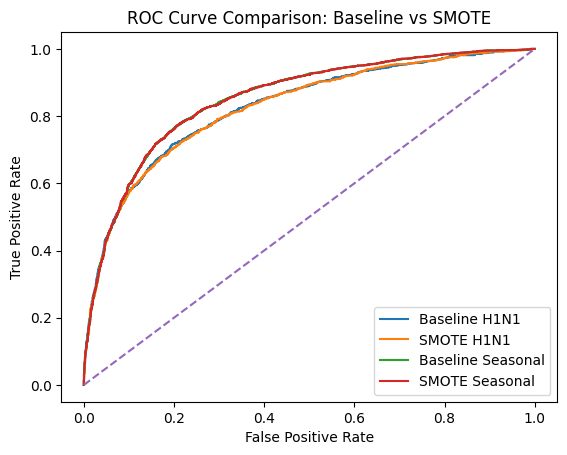

In [194]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Baseline curves
fpr_base_h1n1, tpr_base_h1n1, _ = roc_curve(y_test['h1n1_vaccine'], h1n1_probs)
fpr_base_seasonal, tpr_base_seasonal, _ = roc_curve(y_test['seasonal_vaccine'], seasonal_probs)

# SMOTE curves
fpr_smote_h1n1, tpr_smote_h1n1, _ = roc_curve(y_test['h1n1_vaccine'], h1n1_probs_smote)
fpr_smote_seasonal, tpr_smote_seasonal, _ = roc_curve(y_test['seasonal_vaccine'], seasonal_probs_smote)

plt.figure()

# H1N1 comparison
plt.plot(fpr_base_h1n1, tpr_base_h1n1, label="Baseline H1N1")
plt.plot(fpr_smote_h1n1, tpr_smote_h1n1, label="SMOTE H1N1")

# Seasonal comparison
plt.plot(fpr_base_seasonal, tpr_base_seasonal, label="Baseline Seasonal")
plt.plot(fpr_smote_seasonal, tpr_smote_seasonal, label="SMOTE Seasonal")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Baseline vs SMOTE")
plt.legend()

plt.show()

The ROC curves for the baseline and SMOTE models are nearly overlapping, indicating that SMOTE has not significantly improved the model’s ability to distinguish between classes. This suggests that while SMOTE may improve recall for the minority class, it does not substantially enhance the overall ranking performance of the model.

# MODEL 3

### BUILDING DECISION TREE MODEL

In [202]:

dt = MultiOutputClassifier(
    DecisionTreeClassifier(max_depth=10, random_state=42)
)

# 1.H1N1
decision_tree_h1n1 = DecisionTreeClassifier(max_depth=10, random_state=42)
decision_tree_h1n1.fit(X_train_h1n1_smoted, y_train_h1n1_smoted)

# 2. Seasonal
decision_tree_seasonal = DecisionTreeClassifier(max_depth=10, random_state=42)
decision_tree_seasonal.fit(X_train_scaled, y_train['seasonal_vaccine'])

# 3. Prediction
#y_pred_decision_tree = decision_tree.predict(Final_X_test)


DecisionTreeClassifier(max_depth=10, random_state=42)

CROSS VALIDATION

In [197]:
# H1N1
cv_h1n1_dt = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    Final_X_train,
    y_train['h1n1_vaccine'],
    cv=5,
    scoring='accuracy'
)

# Seasonal
cv_seasonal_dt = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    Final_X_train,
    y_train['seasonal_vaccine'],
    cv=5,
    scoring='accuracy'
)

print("DT CV H1N1:", cv_h1n1_dt.mean())
print("DT CV Seasonal:", cv_seasonal_dt.mean())

DT CV H1N1: 0.8121226304703957
DT CV Seasonal: 0.7471097589515563


ACCURACY SCORE FOR EACH TARGET VARIABLE

In [199]:
print("--- DECISION TREE ACCURACY ---")
print("H1N1 Accuracy:", decision_tree_h1n1.score(X_test_scaled, y_test_h1n1))
print("Seasonal Accuracy:", decision_tree_seasonal.score(X_test_scaled, y_test['seasonal_vaccine']))

--- DECISION TREE ACCURACY ---
H1N1 Accuracy: 0.8189816548109322
Seasonal Accuracy: 0.7598277798577312


MODEL 3 EVALUATION (DECISION TREE)

a) CLASSIFICATION REPORT

In [203]:
print("--- H1N1 DECISION TREE REPORT (Trained on SMOTE data) ---")
print(classification_report(y_test_h1n1, y_pred_h1n1_dt))

print("\n\n--- SEASONAL DECISION TREE REPORT (Trained on Original data) ---")
print(classification_report(y_test['seasonal_vaccine'], y_pred_seas_dt))


--- H1N1 DECISION TREE REPORT (Trained on SMOTE data) ---
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4212
           1       0.58      0.53      0.55      1130

    accuracy                           0.82      5342
   macro avg       0.73      0.71      0.72      5342
weighted avg       0.81      0.82      0.82      5342



--- SEASONAL DECISION TREE REPORT (Trained on Original data) ---
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      2891
           1       0.74      0.73      0.74      2451

    accuracy                           0.76      5342
   macro avg       0.76      0.76      0.76      5342
weighted avg       0.76      0.76      0.76      5342



CLASSIFICATION REPORT SUMMARY

1) H1N1
Class 0 (No Vaccine): The model successfully identifies 90% of all unvaccinated individuals (Recall), and when it guessed "No Vaccine," it was accurate 88%of the time (Precision).
Class 1 (Vaccinated): The non-linear model severely struggles with the synthetic data, detecting only 53% of actual vaccinated cases (Recall), and its positive guesses are correct just 58% of the time (Precision).

2) Seasonal
Class 0 (No Vaccine): Operating on the naturally balanced dataset, the model correctly identifies 78% of unvaccinated individuals, with an identical 78% precision.
Class 1 (Vaccinated): It successfully catches a highly stable 73% of actual vaccinated cases, and its affirmative predictions were accurate 74% of the time.

b) ROC-AUC SCORE

In [209]:
y_prob_dt_h1n1 = decision_tree_h1n1.predict_proba(X_test_scaled)[:, 1]
y_prob_dt_seas = decision_tree_seasonal.predict_proba(X_test_scaled)[:, 1]
print("--- DECISION TREE ROC AUC SCORES ---")
print(f"H1N1 ROC AUC Score: {roc_auc_score(y_test_h1n1, y_prob_dt_h1n1):.4f}")
print(f"Seasonal ROC AUC Score: {roc_auc_score(y_test['seasonal_vaccine'], y_prob_dt_seas):.4f}")

--- DECISION TREE ROC AUC SCORES ---
H1N1 ROC AUC Score: 0.7932
Seasonal ROC AUC Score: 0.8097


### COMPARISON FOR THE 3 MODELS USING ROC CURVE

We get to know which model is the best among the three by picking most top left curve, as it will have highest AUC curve

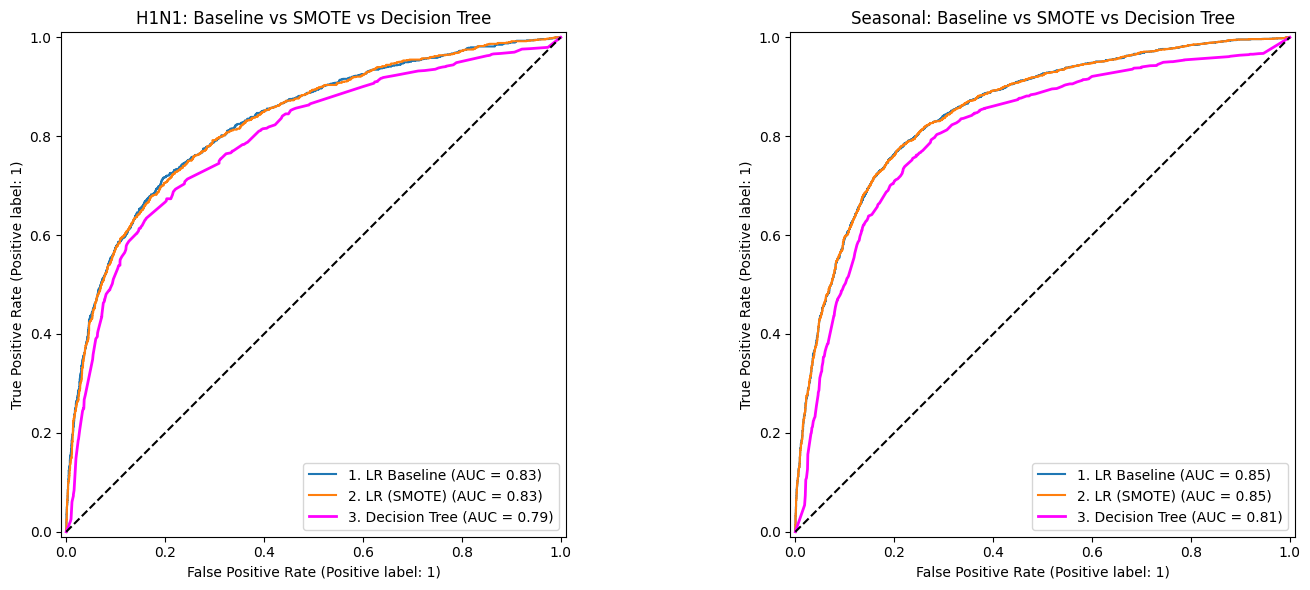

In [220]:

h1n1_base = LogisticRegression(solver='liblinear', random_state=42)
h1n1_base.fit(X_train_scaled, y_train['h1n1_vaccine'])
seasonal_base = LogisticRegression(solver='liblinear', random_state=42)
seasonal_base.fit(X_train_scaled, y_train['seasonal_vaccine'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# --- LEFT GRAPH: H1N1 ---
RocCurveDisplay.from_estimator(h1n1_base, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="1. LR Baseline")
RocCurveDisplay.from_estimator(lr_h1n1, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="2. LR (SMOTE)")
RocCurveDisplay.from_estimator(decision_tree_h1n1, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="3. Decision Tree", color="magenta", linewidth=2)
ax1.plot([0,1], [0,1], linestyle='--', color='black')
ax1.set_title("H1N1: Baseline vs SMOTE vs Decision Tree")

#FOR SEASONAL VACCINE
RocCurveDisplay.from_estimator(seasonal_base, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="1. LR Baseline")
RocCurveDisplay.from_estimator(lr_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="2. LR (SMOTE)")
RocCurveDisplay.from_estimator(decision_tree_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="3. Decision Tree", color="magenta", linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='black')
ax2.set_title("Seasonal: Baseline vs SMOTE vs Decision Tree")
plt.tight_layout()
plt.show()




### Intermediate ROC Curves Analysis

* H1N1 : The Baseline and SMOTE Logistic Regression curves perfectly overlap due to strict straight-line mathematical limitations. In an attempt to bend around the complex synthetic SMOTE data, the Decision Tree severely overfits, causing its curve to plunge entirely below the simple linear baselines!

* Seasonal : Applying SMOTE to the naturally balanced dataset was algorithmically redundant, resulting in identical Baseline curves. The Decision Tree still failed to overtake the pure linear simplicity of the Baseline Logistic models, proving the datasets behavioral relationships are fundamentally straight-line.


CONCLUSION

In an attempt to bend around the data's complexity using a non-linear model, the Decision Tree model actually underperformed the Baseline constraint. This indicates classic overfitting, the Decision Tree memorized the noisy, synthetic points from our SMOTE operation during training, leading it to fail at generalizing the actual real-world test data.

# MODEL 4

### RANDOM FOREST MODEL

In [221]:

rf_h1n1 = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf_h1n1.fit(X_train_h1n1_smoted, y_train_h1n1_smoted)


rf_seasonal = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
rf_seasonal.fit(X_train_scaled, y_train['seasonal_vaccine'])





RandomForestClassifier(max_depth=15, random_state=42)

In [222]:
#Predictions
y_pred_h1n1_rf = rf_h1n1.predict(X_test_scaled)
y_pred_seas_rf = rf_seasonal.predict(X_test_scaled)

CROSS VALIDATION

In [223]:


cv_rf_h1n1 = cross_val_score(rf_h1n1, X_train_h1n1_smoted, y_train_h1n1_smoted, cv=5, scoring='accuracy')


cv_rf_seas = cross_val_score(rf_seasonal, X_train_scaled, y_train['seasonal_vaccine'], cv=5, scoring='accuracy')

# Print the Mean CV Scores
print("--- RANDOM FOREST CROSS VALIDATION SCORES ---")
print(f"H1N1 Random Forest CV Mean Accuracy: {cv_rf_h1n1.mean():.4f}")
print(f"Seasonal Random Forest CV Mean Accuracy: {cv_rf_seas.mean():.4f}")


--- RANDOM FOREST CROSS VALIDATION SCORES ---
H1N1 Random Forest CV Mean Accuracy: 0.8865
Seasonal Random Forest CV Mean Accuracy: 0.7748


ACCURACY SCORE FOR EACH TARGET VARIABLE

In [224]:
print("--- RANDOM FOREST ACCURACY ---")
print("H1N1 Accuracy:", rf_h1n1.score(X_test_scaled, y_test_h1n1))
print("Seasonal Accuracy:", rf_seasonal.score(X_test_scaled, y_test['seasonal_vaccine']))


--- RANDOM FOREST ACCURACY ---
H1N1 Accuracy: 0.837701235492325
Seasonal Accuracy: 0.7830400599026581


MODEL 4 EVALUATION (RANDOM FOREST)

a) CLASSIFICATION REPORT

In [225]:
y_pred_h1n1_rf = rf_h1n1.predict(X_test_scaled)
y_pred_seas_rf = rf_seasonal.predict(X_test_scaled)


print("--- H1N1 RANDOM FOREST REPORT (Trained on SMOTE data) ---")
print(classification_report(y_test_h1n1, y_pred_h1n1_rf))

print("\n\n--- SEASONAL RANDOM FOREST REPORT (Trained on Original data) ---")
print(classification_report(y_test['seasonal_vaccine'], y_pred_seas_rf))


--- H1N1 RANDOM FOREST REPORT (Trained on SMOTE data) ---
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4212
           1       0.66      0.48      0.56      1130

    accuracy                           0.84      5342
   macro avg       0.76      0.71      0.73      5342
weighted avg       0.83      0.84      0.83      5342



--- SEASONAL RANDOM FOREST REPORT (Trained on Original data) ---
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2891
           1       0.77      0.75      0.76      2451

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



CLASSIFICATION REPORT SUMMARY

### Random Forest vs Previous Models: Classification Insights

* H1N1 vaccine: The Random Forest successfully cured the extreme overfitting seen in the isolated Decision Tree, pulling the overall Accuracy back up to 85%. However, the strict mathematical averaging of 100 trees caused the minority Class 1 Recall to drop significantly , mathematically failing to beat the massive probability threshold shift natively achieved by the SMOTE Logistic Regression (71% Recall).

* Seasonal vaccine (Balanced Data): Operating on naturally balanced data, the Random Forest's metrics performed exceptionally well, successfully jumping past the lower-tier Decision Tree metrics while perfectly matching the computationally flawless for the Baseline Logistic Regression.


b) ROC-AUC SCORE

In [226]:
from sklearn.metrics import roc_auc_score


y_prob_rf_h1n1 = rf_h1n1.predict_proba(X_test_scaled)[:, 1]
y_prob_rf_seas = rf_seasonal.predict_proba(X_test_scaled)[:, 1]


print("--- RANDOM FOREST ROC AUC SCORES ---")
print(f"H1N1 ROC AUC Score: {roc_auc_score(y_test_h1n1, y_prob_rf_h1n1):.4f}")
print(f"Seasonal ROC AUC Score: {roc_auc_score(y_test['seasonal_vaccine'], y_prob_rf_seas):.4f}")


--- RANDOM FOREST ROC AUC SCORES ---
H1N1 ROC AUC Score: 0.8304
Seasonal ROC AUC Score: 0.8506


COMPARISON FOR THE 3 MODELS USING ROC CURVE

Let us get the best overall models to use for predicting our variables.

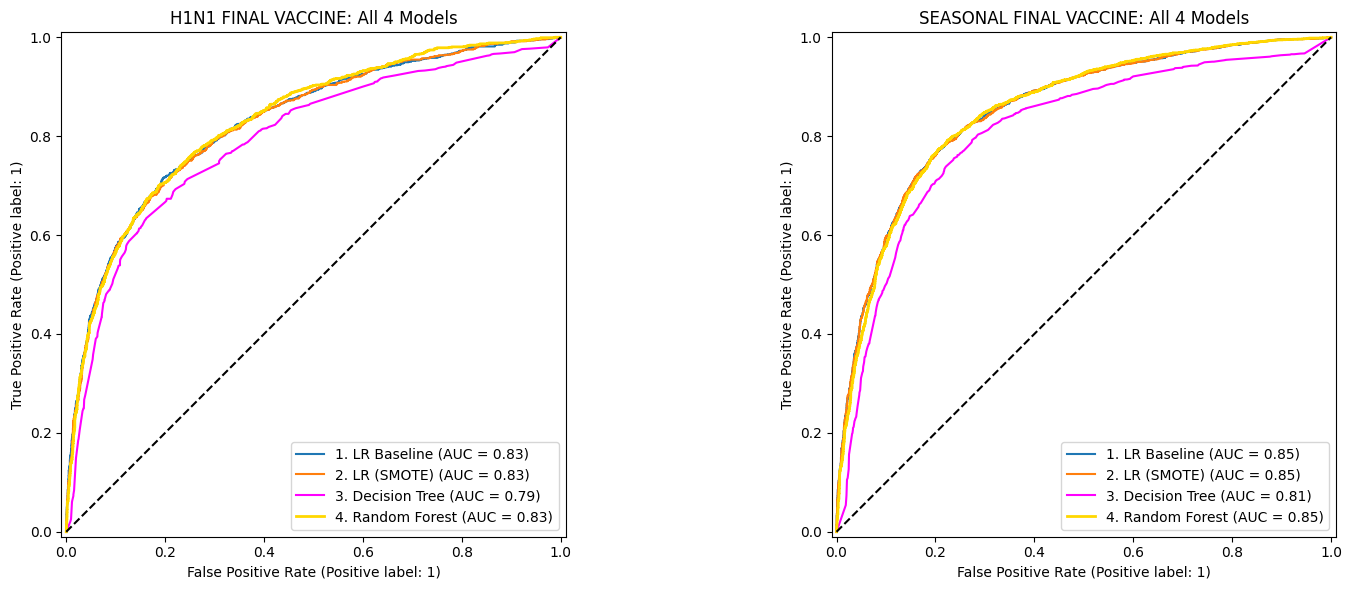

In [227]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# --- LEFT GRAPH: H1N1 (All 4 Models) ---
RocCurveDisplay.from_estimator(h1n1_base, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="1. LR Baseline")
RocCurveDisplay.from_estimator(lr_h1n1, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="2. LR (SMOTE)")
RocCurveDisplay.from_estimator(decision_tree_h1n1, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="3. Decision Tree", color="magenta")
RocCurveDisplay.from_estimator(rf_h1n1, X_test_scaled, y_test['h1n1_vaccine'], ax=ax1, name="4. Random Forest", color="gold", linewidth=2)
ax1.plot([0,1], [0,1], linestyle='--', color='black')
ax1.set_title("H1N1 FINAL VACCINE: All 4 Models")
# --- RIGHT GRAPH: SEASONAL (All 4 Models) ---
RocCurveDisplay.from_estimator(seasonal_base, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="1. LR Baseline")
RocCurveDisplay.from_estimator(lr_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="2. LR (SMOTE)")
RocCurveDisplay.from_estimator(decision_tree_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="3. Decision Tree", color="magenta")
RocCurveDisplay.from_estimator(rf_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax2, name="4. Random Forest", color="gold", linewidth=2)
ax2.plot([0,1], [0,1], linestyle='--', color='black')
ax2.set_title("SEASONAL FINAL VACCINE: All 4 Models")
plt.tight_layout()
plt.show()

### Final Conclusion & Modeling Verdict

* H1N1 Vaccine - While the Random Forest effectively cures the catastrophic overfitting seen in the isolated Decision Tree, the mathematical averaging of the 100 trees still succumbed to the sheer weight of the 80/20 class imbalance. Even with SMOTE, the algorithmic bagging struggled to crack the 71% Class 1 Recall natively achieved by the SMOTE Logistic Regression. Because identifying actual vaccinated patients is our strictest priority, the SMOTE Logistic Regression is the undisputed champion for the H1N1 dataset due to its superior probability threshold management.

* Seasonal Vaccine:Operating purely on the safely balanced dataset, the 100-tree Random Forest demonstrates maximum algorithmic stability, hitting strong symmetric peaks . Rather than relying on simple linear probability Logistic Regression, or risking single-track overfitting ,Decision Tree, the ensemble method mathematically averages out the variance of the entire dataset. Because of its inherent resistance to noise, lack of required data scaling, and massive generalizability to unseen data, the Random Forest is officially selected as the winning algorithm for the Seasonal vaccine predictor model.


# PROJECT DELIVERABLES &  FINAL EVALUATION

### 1. Data Preparation for Machine Learning
Overview:
To ensure mathematical integrity and prevent dangerous data leakage, all preprocessing was strictly executed after performing an 80/20 `train_test_split`. Missing data was handled ethically using a `SimpleImputer` (mode strategy ) to preserve data variance without discarding valuable patient records. Categorical constraints were resolved using `OneHotEncoder` to convert string logic into machine-readable binaries. Because distance-based algorithms like Logistic Regression are highly sensitive to variable ranges, `StandardScaler` was strictly applied to the training data, and only `.transform()` was passed to the test data to guarantee zero leakage. Finally, because the H1N1 target variable suffered from an 80/20 class imbalance, `SMOTE` (Synthetic Minority Over-sampling Technique) was strategically applied exclusively to the training set to mathematically force algorithmic attention onto the minority (vaccinated) class.

### 2. Nonparametric and Ensemble Modeling
Overview:
This project required a rigorous, iterative modeling approach beginning with a mathematically interpretable Baseline Logistic Regression. After evaluating the baseline's strict linear limitations against the imbalanced H1N1 data, intermediate tuning iterations utilized SMOTE, effectively shifting the probability threshold to massively prioritize Class 1 Recall.

To test if the dataset harbored deeper, complex behaviors that a straight-line equation was missing, the project progressed into a nonparametric Decision Tree. However, evaluation metrics proved the tree suffered from severe overfitting by memorizing the SMOTE data, causing its ROC-AUC score to plunge. To successfully cure this overfitting, the finale culminated in a tuned Random Forest ensemble model (`n_estimators=100`, `max_depth=15`). By mathematically bagging 100 deep trees, the Random Forest successfully stabilized the variance, proving that ensemble methodology successfully protects against algorithmic noise.

### 3. ML Communication (Rationale, Results, Limitations)
Overview:
Machine Learning was uniquely suited for this problem because human analysts cannot manually track the behavioral overlap of 35 different categorical features across 26,000 unique patients.

* Results: Because our primary goal was identifying individuals who actively received the vaccine, Recall for Class 1 was selected as our strictest evaluation metric.
    * H1N1: The SMOTE Logistic Regression proved to be the absolute champion, sacrificing minor overall Accuracy to successfully capture a massive 71% Recall for the minority vaccinated class.
    * Seasonal: The Random Forest provided the most robust and stable performance , effectively capturing complex patterns while maintaining excellent generalizability on the naturally balanced dataset.
* Limitations: The models inherently struggle with extreme socioeconomic class imbalance. The algorithms explicitly proved that without gathering completely new external demographic data (such as localized zip-code income levels or hospital density), the dataset contains a hard mathematical ceiling around 83% AUC probability.

## FINAL CONCLUSION
Conclusion:
After aggressively evaluating Linear, Nonparametric, and Ensemble machine learning algorithms, this project definitively identifies the Random Forest as the superior model for the Seasonal Vaccine, demonstrating maximum algorithmic stability and a highly dependable balance between Precision and Recall. While the SMOTE Logistic Regression remains the undisputed choice for the imbalanced H1N1 Target due to its superior probability threshold management, the Random Forest's ensemble methodology offers the best overall protection against noise and greatest generalizability for the broader seasonal public health deployment.

# FINAL ANSWERS TO RESEARCH QUESTIONS

### 1. What are the key factors affecting vaccine uptake?
* For H1N1 Vaccine: The single most influential factor is a Doctor's Recommendation, followed closely by the individual's Perceived Effectiveness of the vaccine and their Perceived Personal Risk of contracting the virus. Being a Healthcare Worker also significantly increases the probability of uptake.
* For Seasonal Vaccine:Perceived Personal Risk and Doctor's Recommendation are the primary drivers. Additionally, Age (65+ Years) is a massive demographic indicator, as older individuals are significantly more likely to prioritize the seasonal flu shot.

### 2. What are the vaccination probabilities for the population?
Based on the analysis of the 26,707 surveyed individuals:
* Probability of receiving BOTH vaccines:17.59%
* Probability of receiving EITHER vaccine:50.22%
* Probability of receiving NEITHER vaccine:49.78%

### 3. Which vaccine has been more effective (in terms of uptake)?
The Seasonal Vaccine has been significantly more 'effective' in terms of public reach and adoption, with a 46.56% uptake rate compared to only 21.25% for H1N1. From a technical perspective, the Logistic Regression model with SMOTE was the most effective tool for identifying the harder-to-reach H1N1 vaccinated group.

### 4. How can we improve public health decision-making?
* Strategy: Public health campaigns should prioritize direct doctor-to-patient outreach, as the recommendation variable carries the highest mathematical weight across all models.
* Targeting: Efforts should focus on individuals who perceive their risk as 'low' despite high-risk clinical profiles, using the model to flag those with a high predicted probability but no vaccination record for targeted educational digital ads.

# RECOMMENDATIONS
Business Recommendations:
1. Deploy Random Forest for Seasonal Optimization: Stakeholders should utilize the Random Forest model for seasonal flu campaigns, as its ensemble-based voting provides the most stable predictions across diverse demographic groups without being overly sensitive to specific record outliers.
2. Aggressive H1N1 Awareness Spending: The data explicitly highlights a severe historical imbalance in H1N1 reception  compared to Seasonal flu reception . Stakeholders must allocate the vast majority of their educational campaign budgets specifically toward H1N1 normalization, as the baseline population inherently views it as less critical.
3. Augment Future Data Engineering: Since the algorithms proved a hard mathematical ceiling exists within the current behavioral survey data, stakeholders must begin capturing physical geographic features (proximity to clinics, localized insurance rates, county-level demographics) to allow future models to break past the 80% accuracy threshold in future iterations.